<a href="https://colab.research.google.com/github/luangz19/Analise-de-Dados/blob/main/E-commerce-Marketing-and-Sales-Revenue/3_Gr%C3%A1ficos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 - Importação dos Dados

In [135]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amineipad/e-commerce-marketing-and-sales-revenue-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'e-commerce-marketing-and-sales-revenue-prediction' dataset.
Path to dataset files: /kaggle/input/e-commerce-marketing-and-sales-revenue-prediction


In [136]:
import os

os.listdir(path)

['train.csv', 'test.csv']

In [137]:
import pandas as pd
import seaborn as sns

In [138]:
data_train = pd.read_csv(path + '/train.csv')
data_test = pd.read_csv(path + '/train.csv')

# 2 - Resumo de Dados

In [139]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       18000 non-null  int64  
 1   date                     18000 non-null  object 
 2   region                   18000 non-null  object 
 3   channel                  18000 non-null  object 
 4   product_category         18000 non-null  object 
 5   customer_segment         18000 non-null  object 
 6   ad_spend                 17342 non-null  float64
 7   price                    18000 non-null  float64
 8   discount_rate            17245 non-null  float64
 9   market_reach             17314 non-null  float64
 10  impressions              18000 non-null  int64  
 11  click_through_rate       17287 non-null  float64
 12  competition_index        17293 non-null  float64
 13  seasonality_index        18000 non-null  float64
 14  campaign_duration_days

## 2.1 - Leitura das primeiras linhas

In [140]:
data_train.head()

,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
0,1,2011-12-05 11:31:00,Nort,Search,General,Standard,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.49,119.767811
1,2,2011-04-27 14:01:00,North,Social Media,General,Premium,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.16,119.404661
2,3,2010-11-09 15:20:00,North,Affiliate,General,Budget,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.74,132.009747
3,4,2010-10-03 15:24:00,North,Affiliate,Storage,Premium,2.95,2.95,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.85,154.511756
4,5,2011-10-14 09:28:00,North,Search,Lighting,Premium,15.00,1.25,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.28,128.059924


## 2.2 - Nome das colunas

In [141]:
data_train.columns

Index(['id', 'date', 'region', 'channel', 'product_category',
       'customer_segment', 'ad_spend', 'price', 'discount_rate',
       'market_reach', 'impressions', 'click_through_rate',
       'competition_index', 'seasonality_index', 'campaign_duration_days',
       'customer_lifetime_value', 'sales_revenue'],
      dtype='object')

In [142]:
for i in data_train.columns:
  if data_train[i].dtype == "object":
    print(f"{i}:", data_train[i].unique(), "\n")

date: ['2011-12-05 11:31:00' '2011-04-27 14:01:00' '2010-11-09 15:20:00' ...
 '2011-01-13 13:21:00' '2010-11-09 14:11:00' '2011-11-20 12:11:00'] 

region: ['Nort' 'North' 'north' 'NORTH' 'Central' 'Norht' 'north ' 'East' 'West'
 'South'] 

channel: ['Search' 'Social Media' 'Affiliate' 'Email' 'TV' 'Influencer'
 'Social_Media' 'Socail Media' 'social Media' 'SocialMedia' 'social media'] 

product_category: ['General' 'Storage' 'Lighting' 'Stationery' 'Kitchen' 'Seasonal'] 

customer_segment: ['Standard' 'Premium' 'Budget'] 



In [143]:
print(data_train["region"].value_counts())

region
North      16305
East         374
Norht        248
north        242
NORTH        209
Nort         200
north        199
Central      109
West          77
South         37
Name: count, dtype: int64


## 2.3 - Padronizando os nomes da coluna region

In [144]:
def cap(x):
  x = x.capitalize()
  if x == "Norht" or x == "Nort" or x == "North ":
    x = "North"
  return x

data_train["region"] = data_train["region"].apply(cap)
data_train["region"].value_counts()

,count
region,
North,17403
East,374
Central,109
West,77
South,37


In [145]:
print(data_train["channel"].value_counts())

channel
Social Media    4246
Email           3625
Search          3600
Affiliate       2632
TV              1848
Influencer      1806
social Media      55
SocialMedia       50
Social_Media      48
Socail Media      45
social media      45
Name: count, dtype: int64


## 2.4 Padronizando os nomes da coluna channel

In [146]:


def cap2(x):
  palavra = ""
  x = x.capitalize()
  for i in x:
    palavra += i
    if palavra == "Soc":
      x = "Social Media"
      break
      return x
  return x


In [147]:
data_train["channel"] = data_train["channel"].apply(cap2)
data_train["channel"].value_counts()

,count
channel,
Social Media,4489
Email,3625
Search,3600
Affiliate,2632
Tv,1848
Influencer,1806


In [148]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       18000 non-null  int64  
 1   date                     18000 non-null  object 
 2   region                   18000 non-null  object 
 3   channel                  18000 non-null  object 
 4   product_category         18000 non-null  object 
 5   customer_segment         18000 non-null  object 
 6   ad_spend                 17342 non-null  float64
 7   price                    18000 non-null  float64
 8   discount_rate            17245 non-null  float64
 9   market_reach             17314 non-null  float64
 10  impressions              18000 non-null  int64  
 11  click_through_rate       17287 non-null  float64
 12  competition_index        17293 non-null  float64
 13  seasonality_index        18000 non-null  float64
 14  campaign_duration_days

# 3 - Tipos de dados

## 3.1 - Dados Qualitativos

In [149]:
dados_qualitativos = [i for i in data_train.columns if data_train[i].dtype == "object"]
dados_qualitativos

['date', 'region', 'channel', 'product_category', 'customer_segment']

### 3.1.1 Dados Qualitativos Nominal

In [150]:
dados_qualitativos[1:4]

['region', 'channel', 'product_category']

### 3.1.2 Dados Qualitativos Ordinal

In [151]:
dados_qualitativos[4:]

['customer_segment']

## 3.2 - Dados Quantitativos

In [152]:
dados_quantitativos = [i for i in data_train.columns if data_train[i].dtype != "object"]
dados_quantitativos

['id',
 'ad_spend',
 'price',
 'discount_rate',
 'market_reach',
 'impressions',
 'click_through_rate',
 'competition_index',
 'seasonality_index',
 'campaign_duration_days',
 'customer_lifetime_value',
 'sales_revenue']

### 3.2.1 Dados Discretos

In [153]:
for i in dados_quantitativos[1:]:
    if data_train[i].dtype == "int64":
      print(i)

impressions


### 3.2.1 Dados Contínuos

In [154]:
for i in dados_quantitativos[1:]:
    if data_train[i].dtype == "float64":
      print(i)

ad_spend
price
discount_rate
market_reach
click_through_rate
competition_index
seasonality_index
campaign_duration_days
customer_lifetime_value
sales_revenue


# 5 - Gráficos



## 5.1 - Gráficos para Variávies Qualitativas

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

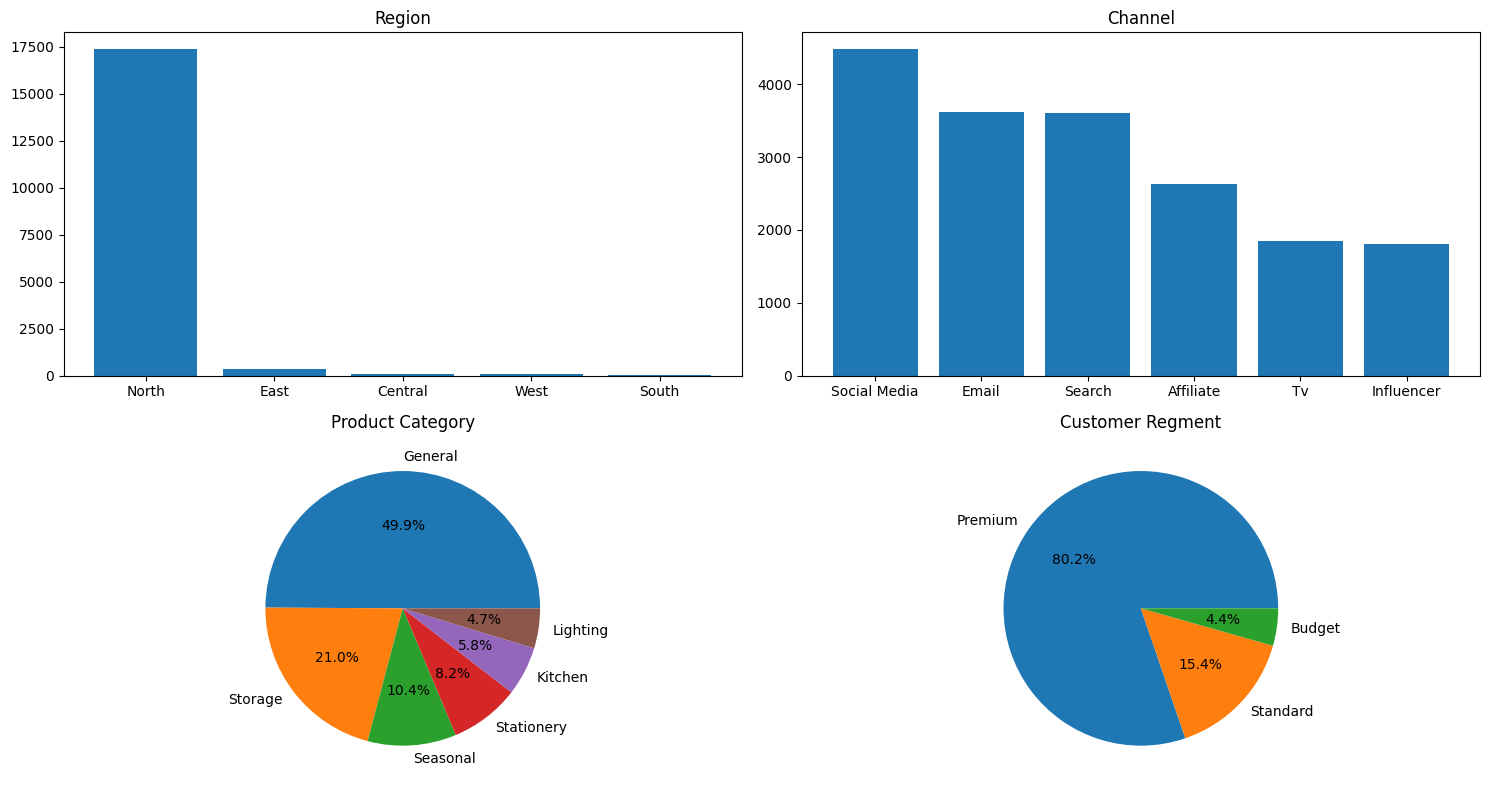

In [156]:
fig, ax = plt.subplots(2,2, figsize=(15,8))
ax[0,0].bar(x=data_train["region"].value_counts().index, height=data_train["region"].value_counts().values)
ax[0,0].set_title("Region")

ax[0,1].bar(x=data_train["channel"].value_counts().index, height=data_train["channel"].value_counts().values)
ax[0,1].set_title("Channel")

ax[1,0].pie(x=data_train["product_category"].value_counts().values, labels=data_train["product_category"].value_counts().index, autopct='%1.1f%%')
ax[1,0].set_title("Product Category")

ax[1,1].pie(x=data_train["customer_segment"].value_counts().values, labels=data_train["customer_segment"].value_counts().index, autopct='%1.1f%%')
ax[1,1].set_title("Customer Regment")
plt.tight_layout()

## 5.2 - Gráficos para Variávies Quantitativas

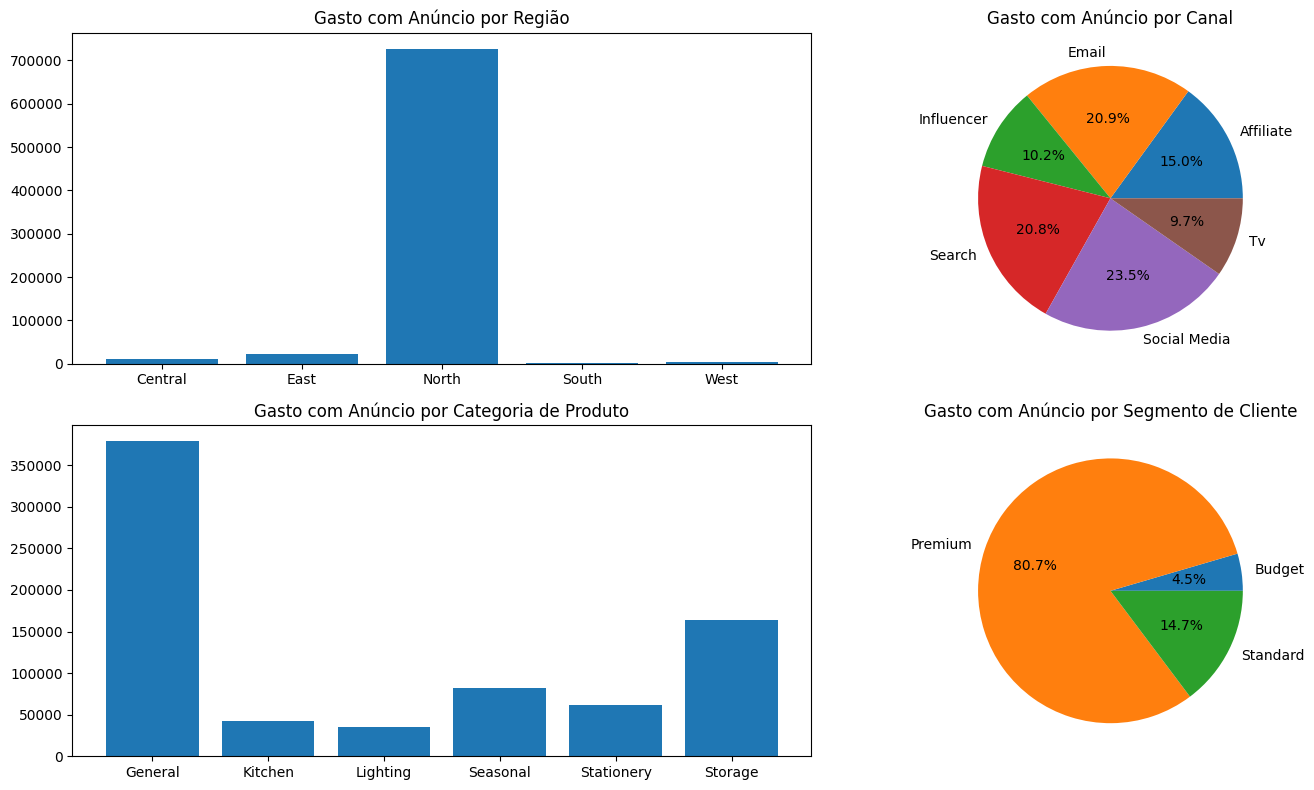

In [157]:
fig, ax = plt.subplots(2,2, figsize=(15,8))
# Qual região teve o maior gasto com anúncio?
ax[0,0].bar(x=data_train.groupby("region")["ad_spend"].sum().index, height=data_train.groupby("region")["ad_spend"].sum().values)
ax[0,0].set_title("Gasto com Anúncio por Região")

# Qual canal teve o maior gasto com anúncio?
ax[0,1].pie(x=data_train.groupby("channel")["ad_spend"].sum().values, labels=data_train.groupby("channel")["ad_spend"].sum().index, autopct='%1.1f%%')
ax[0,1].set_title("Gasto com Anúncio por Canal")

# Qual categoria de produto teve o maior gasto com anúncio?
ax[1,0].bar(x=data_train.groupby("product_category")["ad_spend"].sum().index, height=data_train.groupby("product_category")["ad_spend"].sum().values)
ax[1,0].set_title("Gasto com Anúncio por Categoria de Produto")

# Qual segmento de cliente teve o maior gasto com anúncio?
ax[1,1].pie(x=data_train.groupby("customer_segment")["ad_spend"].sum().values, labels=data_train.groupby("customer_segment")["ad_spend"].sum().index, autopct='%1.1f%%')
ax[1,1].set_title("Gasto com Anúncio por Segmento de Cliente")

plt.tight_layout()

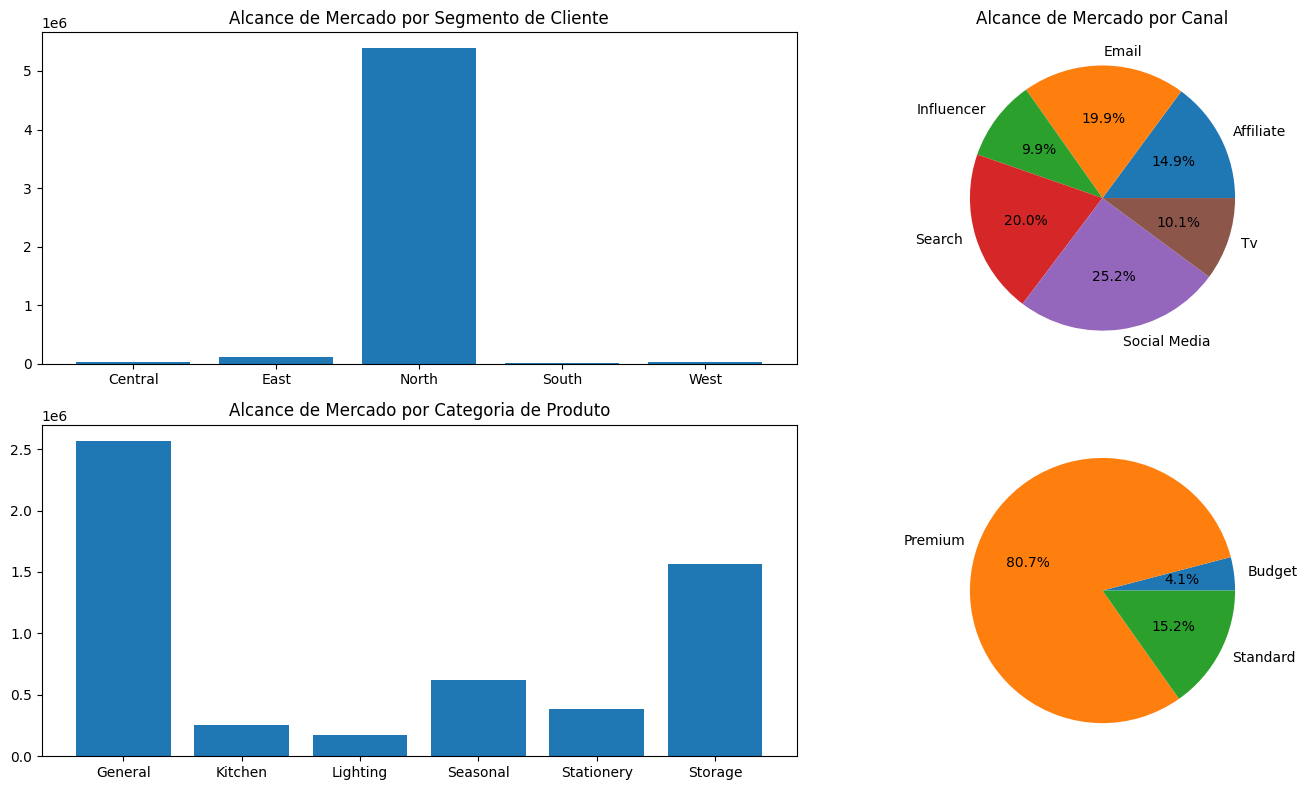

In [158]:
fig, ax = plt.subplots(2,2, figsize=(15,8))

# Qual região teve o maior alcance de mercado?
ax[0,0].bar(x=data_train.groupby("region")["market_reach"].sum().index, height=data_train.groupby("region")["market_reach"].sum().values)
ax[0,0].set_title("Alcance de Mercado por Região")

# Qual canal teve o maior alcance de mercado?
ax[0,1].pie(x=data_train.groupby("channel")["market_reach"].sum().values, labels=data_train.groupby("channel")["market_reach"].sum().index, autopct='%1.1f%%')
ax[0,1].set_title("Alcance de Mercado por Canal")

# Qual categoria de produto teve o maior alcance de mercado?
ax[1,0].bar(x=data_train.groupby("product_category")["market_reach"].sum().index, height=data_train.groupby("product_category")["market_reach"].sum().values)
ax[1,0].set_title("Alcance de Mercado por Categoria de Produto")

# Qual segmento de cliente teve o maior alcance de mercado?
ax[1,1].pie(x=data_train.groupby("customer_segment")["market_reach"].sum().values, labels=data_train.groupby("customer_segment")["market_reach"].sum().index, autopct='%1.1f%%')
ax[0,0].set_title("Alcance de Mercado por Segmento de Cliente")

plt.tight_layout()

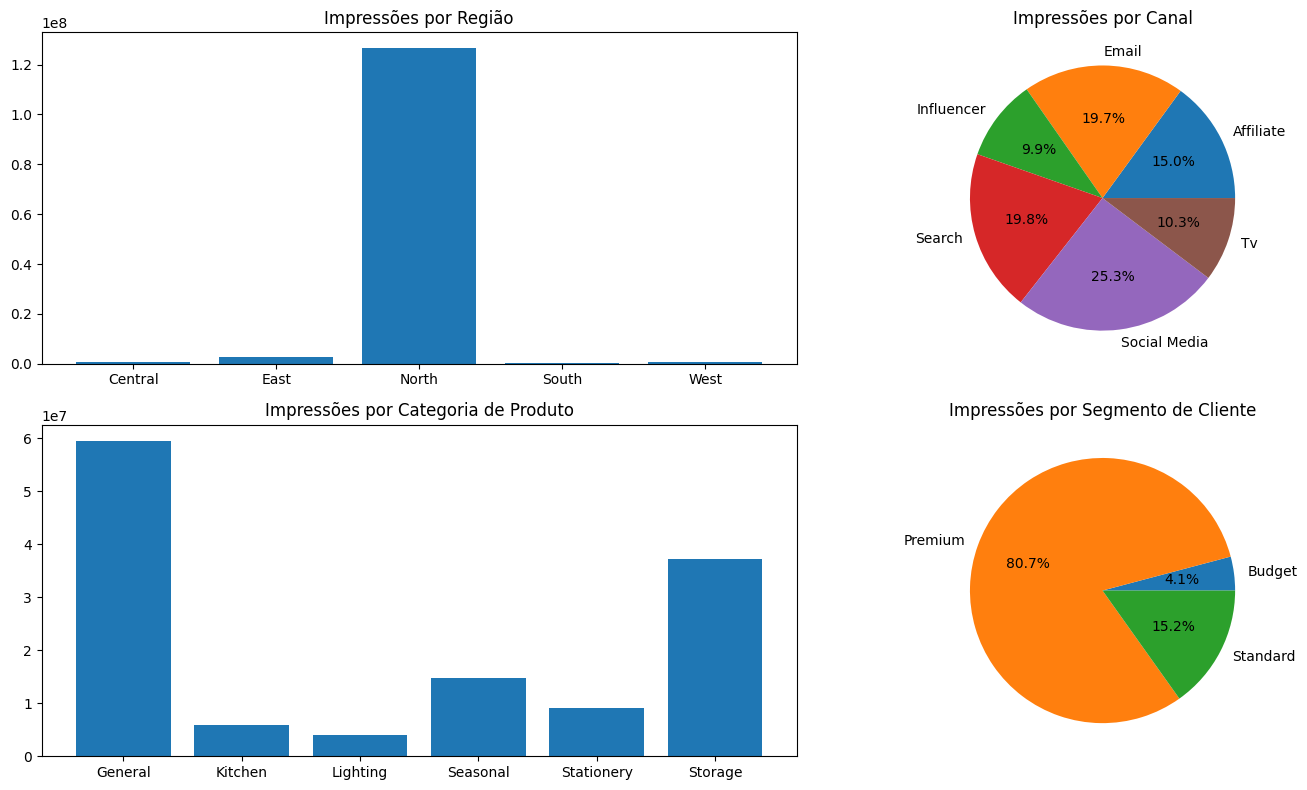

In [159]:
fig, ax = plt.subplots(2,2, figsize=(15,8))

# Qual região teve o maior número de impressões?
ax[0,0].bar(x=data_train.groupby("region")["impressions"].sum().index, height=data_train.groupby("region")["impressions"].sum().values)
ax[0,0].set_title("Impressões por Região")

# Qual canal teve o maior número de impressões?
ax[0,1].pie(x=data_train.groupby("channel")["impressions"].sum().values, labels=data_train.groupby("channel")["impressions"].sum().index, autopct='%1.1f%%')
ax[0,1].set_title("Impressões por Canal")

# Qual categoria de produto teve o maior número de impressões?
ax[1,0].bar(x=data_train.groupby("product_category")["impressions"].sum().index, height=data_train.groupby("product_category")["impressions"].sum().values)
ax[1,0].set_title("Impressões por Categoria de Produto")

# Qual segmento de cliente teve o maior número de impressões?
ax[1,1].pie(x=data_train.groupby("customer_segment")["impressions"].sum().values, labels=data_train.groupby("customer_segment")["impressions"].sum().index, autopct='%1.1f%%')
ax[1,1].set_title("Impressões por Segmento de Cliente")

plt.tight_layout()

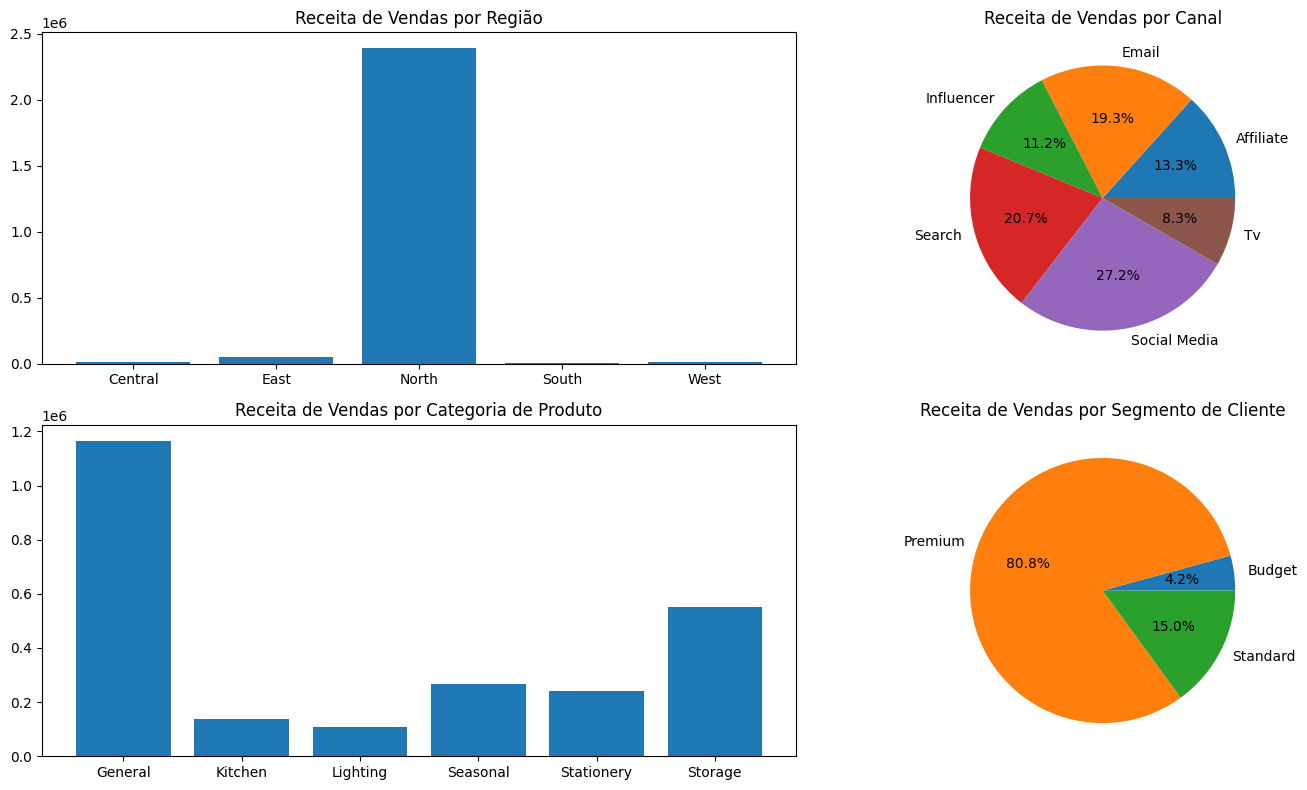

In [160]:
fig, ax = plt.subplots(2,2, figsize=(15,8))

# Qual região teve a maior receita de vendas?
ax[0,0].bar(x=data_train.groupby("region")["sales_revenue"].sum().index, height=data_train.groupby("region")["sales_revenue"].sum().values)
ax[0,0].set_title("Receita de Vendas por Região")

# Qual canal teve a maior receita de vendas?
ax[0,1].pie(x=data_train.groupby("channel")["sales_revenue"].sum().values, labels=data_train.groupby("channel")["sales_revenue"].sum().index, autopct='%1.1f%%')
ax[0,1].set_title("Receita de Vendas por Canal")

# Qual categoria de produto teve a maior receita de vendas?
ax[1,0].bar(x=data_train.groupby("product_category")["sales_revenue"].sum().index, height=data_train.groupby("product_category")["sales_revenue"].sum().values)
ax[1,0].set_title("Receita de Vendas por Categoria de Produto")

# Qual segmento de cliente teve a maior receita de vendas?
ax[1,1].pie(x=data_train.groupby("customer_segment")["sales_revenue"].sum().values, labels=data_train.groupby("customer_segment")["sales_revenue"].sum().index, autopct='%1.1f%%')
ax[1,1].set_title("Receita de Vendas por Segmento de Cliente")

plt.tight_layout()